# ASSIGNMENT 7
## Creating and Fixing Mode Collapse in a GAN

**Objective:**  
To practically understand mode collapse, a common problem during GAN training.


## 1. Import Libraries

I use TensorFlow/Keras to build the GAN, NumPy for data handling, and Matplotlib to display the generated digits.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Load and Preprocess the MNIST Dataset

MNIST contains handwritten digit images of size **28 × 28**.

The images are normalized from `0–255` to `-1 to 1` because the Generator uses the `tanh` activation function.

In [2]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

# Add channel dimension: (28, 28) -> (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)

print("Dataset shape:", x_train.shape)

Dataset shape: (60000, 28, 28, 1)


## 3. Training Settings

We use 20 epochs as requested in the assignment.

`noise_dim = 100` means the Generator starts with a random vector of length 100 and converts it into a handwritten digit.

In [3]:
BATCH_SIZE = 128
EPOCHS = 20
NOISE_DIM = 100

# Drop the last incomplete batch so every training step has a consistent size.
dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(len(x_train))
    .batch(BATCH_SIZE, drop_remainder=True)
)

print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Noise dimension:", NOISE_DIM)

Batch size: 128
Epochs: 20
Noise dimension: 100


# PART A — INTENTIONALLY MAKE THE GAN UNSTABLE

For the broken experiment, the Generator does **not** use Batch Normalization and we deliberately use a high learning rate (`0.002`).

The purpose is to make training less stable and potentially reduce the variety of outputs.

## 4. Build the Broken Generator

This Generator is intentionally simple and has no Batch Normalization.

In [4]:
def build_broken_generator():
    model = tf.keras.Sequential([
        layers.Input(shape=(NOISE_DIM,)),
        layers.Dense(128),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(28 * 28, activation="tanh"),
        layers.Reshape((28, 28, 1))
    ])
    return model

## 5. Build the Discriminator

The Discriminator classifies each image as real or fake.

In [5]:
def build_broken_discriminator():
    model = tf.keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),
        layers.Dense(256),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

## 6. Create the Broken GAN

The learning rate `0.002` is deliberately much higher than the small learning rate normally used in a stable GAN setup.

In [6]:
broken_generator = build_broken_generator()
broken_discriminator = build_broken_discriminator()

cross_entropy = tf.keras.losses.BinaryCrossentropy()

broken_g_optimizer = tf.keras.optimizers.Adam(learning_rate=0.002, beta_1=0.5)
broken_d_optimizer = tf.keras.optimizers.Adam(learning_rate=0.002, beta_1=0.5)

print("Broken GAN created.")

Broken GAN created.


## 7. Train the Broken GAN

In [7]:
@tf.function
def broken_train_step(images):
    current_batch_size = tf.shape(images)[0]
    noise = tf.random.normal([current_batch_size, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = broken_generator(noise, training=True)

        real_output = broken_discriminator(images, training=True)
        fake_output = broken_discriminator(generated_images, training=True)

        gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

        real_loss = cross_entropy(tf.ones_like(real_output), real_output)
        fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
        disc_loss = real_loss + fake_loss

    gen_gradients = gen_tape.gradient(
        gen_loss, broken_generator.trainable_variables
    )
    disc_gradients = disc_tape.gradient(
        disc_loss, broken_discriminator.trainable_variables
    )

    broken_g_optimizer.apply_gradients(
        zip(gen_gradients, broken_generator.trainable_variables)
    )
    broken_d_optimizer.apply_gradients(
        zip(disc_gradients, broken_discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

## 8. Display and Save Broken GAN Output

The same fixed seed is used for the saved snapshots so that progress can be compared visually.

In [8]:
seed = tf.random.normal([16, NOISE_DIM], seed=7)

def show_and_save_images(model, filename, title):
    predictions = model(seed, training=False)
    predictions = (predictions + 1.0) / 2.0
    predictions = tf.clip_by_value(predictions, 0.0, 1.0)

    plt.figure(figsize=(6, 6))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

Epoch 01/20 | Generator Loss: 1.6279 | Discriminator Loss: 0.5374


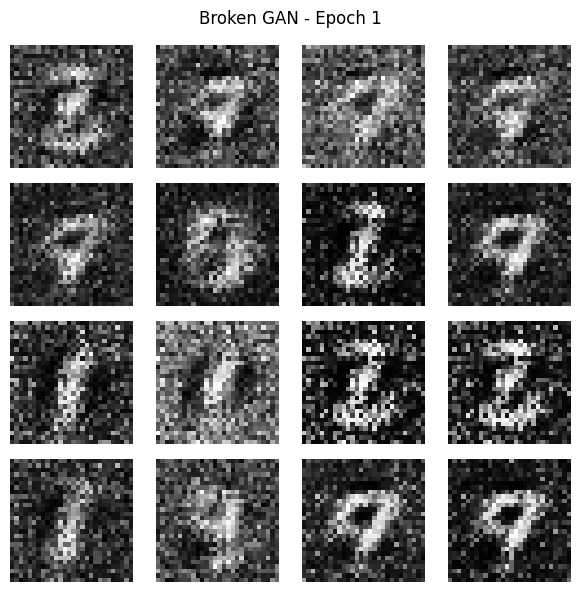

Epoch 02/20 | Generator Loss: 1.1871 | Discriminator Loss: 0.9499
Epoch 03/20 | Generator Loss: 1.9324 | Discriminator Loss: 1.0327
Epoch 04/20 | Generator Loss: 1.7456 | Discriminator Loss: 1.0400
Epoch 05/20 | Generator Loss: 1.8836 | Discriminator Loss: 1.0563


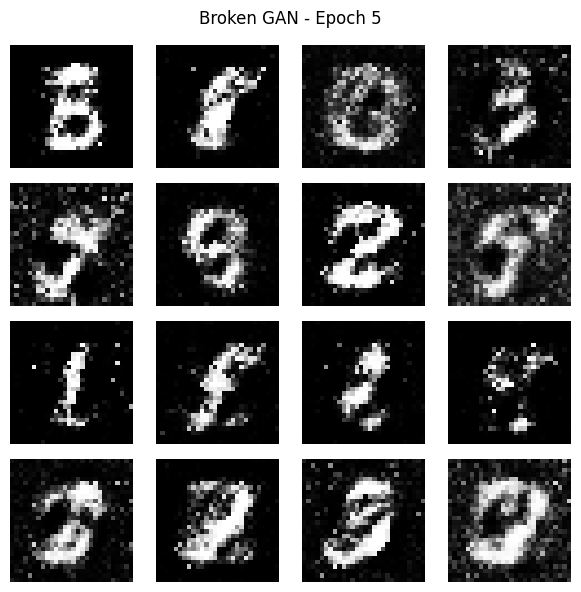

Epoch 06/20 | Generator Loss: 1.3952 | Discriminator Loss: 1.0249
Epoch 07/20 | Generator Loss: 1.8402 | Discriminator Loss: 1.2015
Epoch 08/20 | Generator Loss: 0.4711 | Discriminator Loss: 1.3399
Epoch 09/20 | Generator Loss: 0.5677 | Discriminator Loss: 1.1837
Epoch 10/20 | Generator Loss: 1.8688 | Discriminator Loss: 1.3770


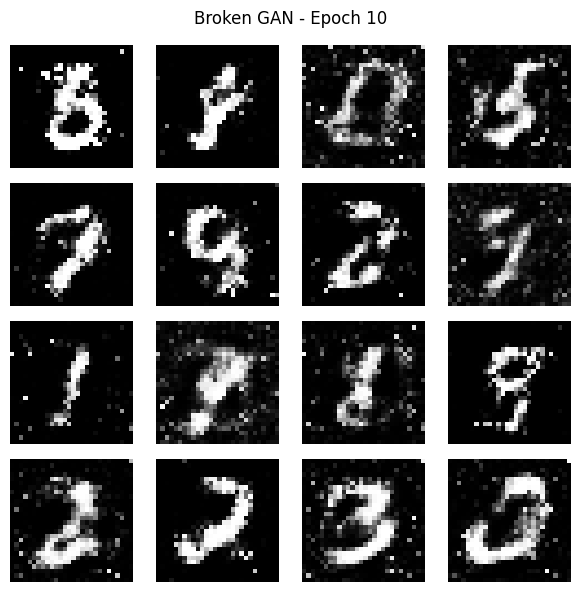

Epoch 11/20 | Generator Loss: 0.6150 | Discriminator Loss: 1.1976
Epoch 12/20 | Generator Loss: 1.0593 | Discriminator Loss: 1.0171
Epoch 13/20 | Generator Loss: 1.4138 | Discriminator Loss: 1.1677
Epoch 14/20 | Generator Loss: 0.3903 | Discriminator Loss: 1.4936
Epoch 15/20 | Generator Loss: 0.5455 | Discriminator Loss: 1.3025


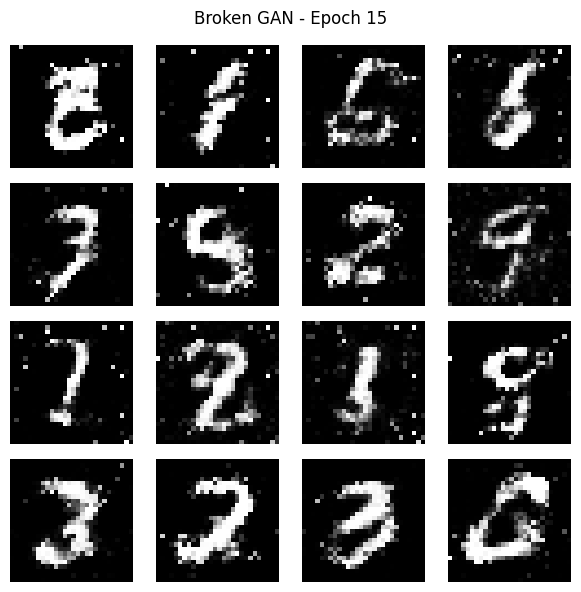

Epoch 16/20 | Generator Loss: 1.7475 | Discriminator Loss: 1.3603
Epoch 17/20 | Generator Loss: 0.7374 | Discriminator Loss: 1.1309
Epoch 18/20 | Generator Loss: 1.0027 | Discriminator Loss: 1.0804
Epoch 19/20 | Generator Loss: 0.5677 | Discriminator Loss: 1.1749
Epoch 20/20 | Generator Loss: 0.6645 | Discriminator Loss: 1.1592


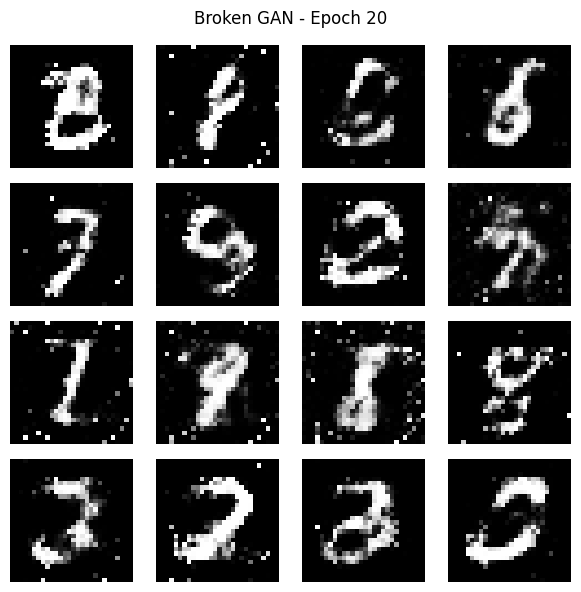

In [9]:
for epoch in range(1, EPOCHS + 1):
    for image_batch in dataset:
        gen_loss, disc_loss = broken_train_step(image_batch)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Generator Loss: {gen_loss.numpy():.4f} | "
        f"Discriminator Loss: {disc_loss.numpy():.4f}"
    )

    if epoch in [1, 5, 10, 15, 20]:
        show_and_save_images(
            broken_generator,
            f"broken_epoch_{epoch}.png",
            f"Broken GAN - Epoch {epoch}"
        )

### Broken output to submit

Use the **Epoch 20** generated image:

`broken_epoch_20.png`

Look for repeated or very similar digits, poor-quality outputs, and reduced variety. These are signs of unstable training/reduced diversity.

# PART B — IMPROVE THE GAN WITH LABEL SMOOTHING

For the improved experiment, we keep the same basic architecture and learning rate so that **label smoothing is the main change**.

Normally the Discriminator receives:
- Real = `1`
- Fake = `0`

With label smoothing:
- Real = `0.9`
- Fake = `0`

## 9. Build the Improved Generator and Discriminator

The architecture remains the same as the broken experiment so the comparison is more meaningful.

In [10]:
def build_improved_generator():
    model = tf.keras.Sequential([
        layers.Input(shape=(NOISE_DIM,)),
        layers.Dense(128),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(28 * 28, activation="tanh"),
        layers.Reshape((28, 28, 1))
    ])
    return model


def build_improved_discriminator():
    model = tf.keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),
        layers.Dense(256),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

## 10. Create the Improved GAN

We keep the same learning rate (`0.002`) to keep the experiment controlled and change the Discriminator's real target from `1.0` to `0.9`.

In [11]:
improved_generator = build_improved_generator()
improved_discriminator = build_improved_discriminator()

improved_g_optimizer = tf.keras.optimizers.Adam(learning_rate=0.002, beta_1=0.5)
improved_d_optimizer = tf.keras.optimizers.Adam(learning_rate=0.002, beta_1=0.5)

print("Improved GAN created.")

Improved GAN created.


## 11. Training Function with Label Smoothing

In [12]:
@tf.function
def improved_train_step(images):
    current_batch_size = tf.shape(images)[0]
    noise = tf.random.normal([current_batch_size, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = improved_generator(noise, training=True)

        real_output = improved_discriminator(images, training=True)
        fake_output = improved_discriminator(generated_images, training=True)

        # Label smoothing: real = 0.9 instead of 1.0
        real_labels = tf.ones_like(real_output) * 0.9
        fake_labels = tf.zeros_like(fake_output)

        gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

        real_loss = cross_entropy(real_labels, real_output)
        fake_loss = cross_entropy(fake_labels, fake_output)
        disc_loss = real_loss + fake_loss

    gen_gradients = gen_tape.gradient(
        gen_loss, improved_generator.trainable_variables
    )
    disc_gradients = disc_tape.gradient(
        disc_loss, improved_discriminator.trainable_variables
    )

    improved_g_optimizer.apply_gradients(
        zip(gen_gradients, improved_generator.trainable_variables)
    )
    improved_d_optimizer.apply_gradients(
        zip(disc_gradients, improved_discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

## 12. Train the Improved GAN

Epoch 01/20 | Generator Loss: 1.5111 | Discriminator Loss: 0.7167


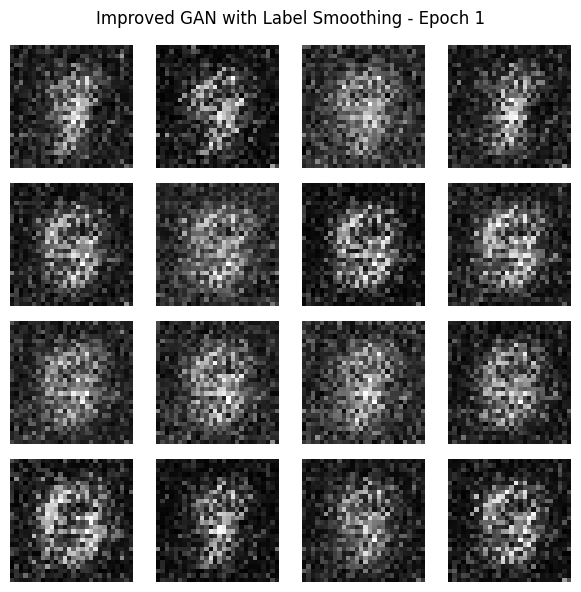

Epoch 02/20 | Generator Loss: 1.3450 | Discriminator Loss: 0.8803
Epoch 03/20 | Generator Loss: 0.7468 | Discriminator Loss: 1.1987
Epoch 04/20 | Generator Loss: 0.9042 | Discriminator Loss: 1.0882
Epoch 05/20 | Generator Loss: 2.3723 | Discriminator Loss: 1.3639


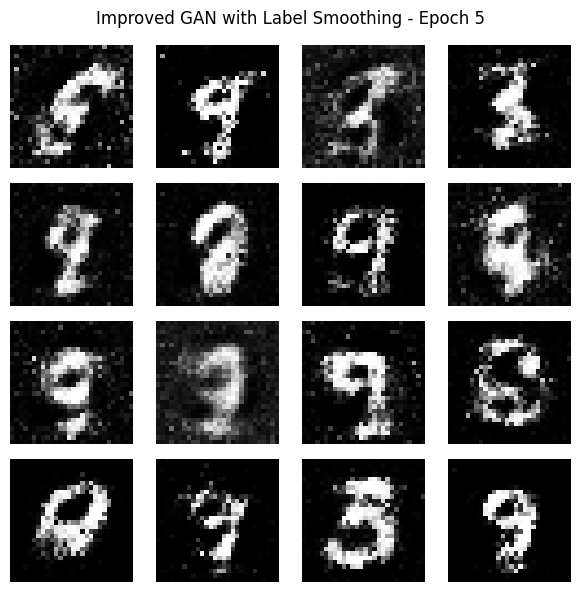

Epoch 06/20 | Generator Loss: 1.7246 | Discriminator Loss: 1.2711
Epoch 07/20 | Generator Loss: 1.4184 | Discriminator Loss: 1.0904
Epoch 08/20 | Generator Loss: 1.2092 | Discriminator Loss: 1.1123
Epoch 09/20 | Generator Loss: 1.0757 | Discriminator Loss: 1.1253
Epoch 10/20 | Generator Loss: 2.2385 | Discriminator Loss: 1.5665


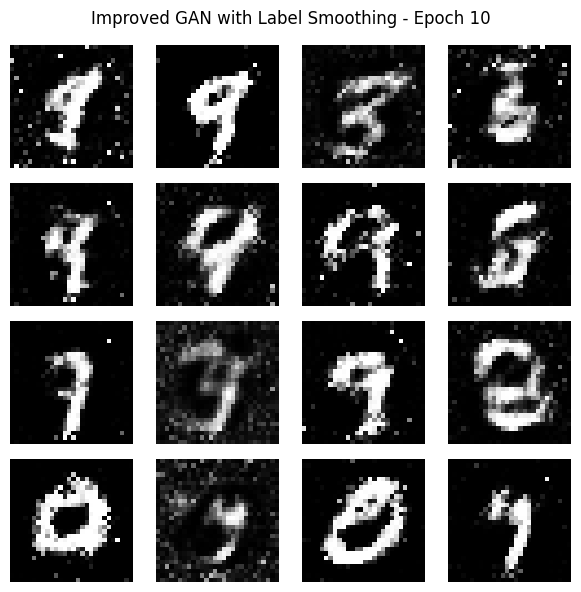

Epoch 11/20 | Generator Loss: 1.2199 | Discriminator Loss: 1.1896
Epoch 12/20 | Generator Loss: 0.7725 | Discriminator Loss: 1.2101
Epoch 13/20 | Generator Loss: 0.7370 | Discriminator Loss: 1.2164
Epoch 14/20 | Generator Loss: 1.5704 | Discriminator Loss: 1.1232
Epoch 15/20 | Generator Loss: 0.8283 | Discriminator Loss: 1.1972


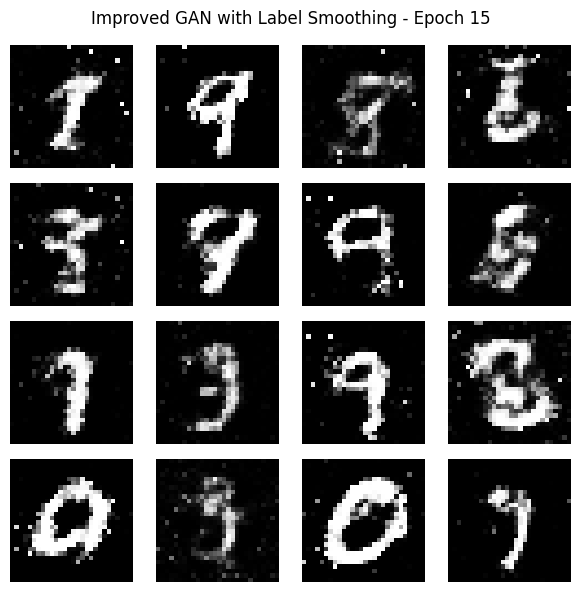

Epoch 16/20 | Generator Loss: 0.8789 | Discriminator Loss: 1.1360
Epoch 17/20 | Generator Loss: 0.8769 | Discriminator Loss: 1.1271
Epoch 18/20 | Generator Loss: 0.6400 | Discriminator Loss: 1.2883
Epoch 19/20 | Generator Loss: 0.9605 | Discriminator Loss: 1.1402
Epoch 20/20 | Generator Loss: 1.3919 | Discriminator Loss: 1.0481


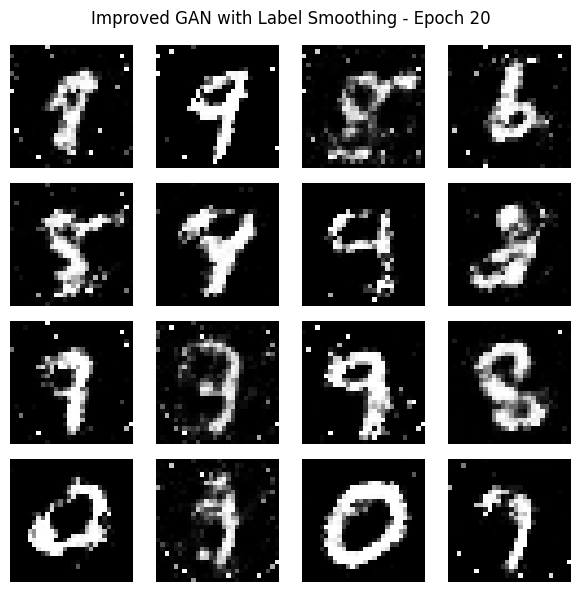

In [13]:
for epoch in range(1, EPOCHS + 1):
    for image_batch in dataset:
        gen_loss, disc_loss = improved_train_step(image_batch)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Generator Loss: {gen_loss.numpy():.4f} | "
        f"Discriminator Loss: {disc_loss.numpy():.4f}"
    )

    if epoch in [1, 5, 10, 15, 20]:
        show_and_save_images(
            improved_generator,
            f"improved_epoch_{epoch}.png",
            f"Improved GAN with Label Smoothing - Epoch {epoch}"
        )

### Improved output to submit

Use the **Epoch 20** generated image:

`improved_epoch_20.png`

Compare it with `broken_epoch_20.png` and check whether the digits are more varied, clearer, or more stable.

# 13. Final Comparison

| Feature | Broken GAN | Improved GAN |
|---|---|---|
| Batch Normalization | Removed | Removed |
| Learning rate | 0.002 | 0.002 |
| Real label | 1.0 | 0.9 |
| Fake label | 0.0 | 0.0 |
| Improvement technique | None | Label smoothing |
| Training | Unstable / reduced diversity | Ideally more stable / diverse |

> **Note:** Because GAN training is stochastic, improvement may vary between runs. Report what your actual screenshots show.



### 1. What modification caused the model to perform poorly?

I intentionally made the GAN unstable by removing Batch Normalization from the Generator and using a higher learning rate of `0.002`. The large learning rate made the Generator and Discriminator update too aggressively, which made training harder to control.

### 2. What did the generated images look like?

The generated images showed reduced variety. Some digits looked very similar, and some images were unclear or poorly formed. This type of repeated output is related to **mode collapse**, where a Generator learns only a small range of outputs instead of producing many different outputs.

### 3. Which technique did you use to improve the problem?

I used **label smoothing**. Instead of telling the Discriminator that every real image is exactly `1.0`, I used `0.9` for real images while keeping fake images at `0.0`.

### 4. Did the solution improve the output? Why?

The purpose of label smoothing is to stop the Discriminator from becoming overly confident. This can give the Generator a more useful learning signal and can improve training stability and output diversity.

I compared the Epoch 20 broken and improved results to judge the actual improvement. Since GANs are sensitive to random initialization, the amount of improvement can differ between runs.

### Conclusion

This experiment helped me understand why GAN training can become unstable. After intentionally making the training difficult, I used label smoothing to make the Discriminator less confident about real images. The comparison helped me understand how GAN training techniques can affect the diversity and quality of generated images.